# 09 · היתוך ברמה גבוהה (High-level Fusion)
**מלווה את ההרצאה:** *High-level Fusion* — Erik Blasch, FUSION Boot Camp 2026 (הרצאה 7).

> ⚠️ שקופיות הרצאה 7 **אינן** ב-PDF, אך הרצאת המבוא של Blasch (מחברת 01) מכסה את היסודות. 
> המחברת מבוססת עליהם ועל הספרות (Blasch, Bossé, Lambert, *High-Level Information Fusion*).

רמות **L0/L1** (מחברות 02–05) עוסקות ב**עצמים**: היכן ומה. רמות **L2–L5** עוסקות ב**משמעות**: 
מה המצב (situation), מה האיום (threat/impact), כיצד לכוון חיישנים (process refinement), ומה האדם צריך (user refinement).

## א. תזכורת — רמות ה-JDL/DFIG הגבוהות
| רמה | שם | שאלה | טכניקות |
|-----|-----|------|---------|
| **L2** | Situation Assessment | מה היחסים בין הישויות? | Bayesian nets, גרפים, ontologies |
| **L3** | Threat / Impact | מה ההשלכות והכוונה (intent)? | game theory, הסקה אבדוקטיבית |
| **L4** | Process Refinement | איך לכוון את החיישנים? | sensor management (מחברת 08) |
| **L5** | User Refinement | מה האדם צריך לראות/להחליט? | HMI, ויזואליזציה, הסבר |

מאפיין מבדיל: ב-L2+ ההסקה היא **אבדוקטיבית** (ההסבר הסביר ביותר) ולעיתים **soft** (טקסט/דיווחי אדם), 
בניגוד להסקה הכמותית/hard ברמות הנמוכות.

## ב. הערכת איום (Threat/Impact Assessment) — דוגמה מספרית
נדגים היתוך **קינמטי + זהותי** לדירוג איום. לכל מטרה נחשב מדד איום שמשלב:
* **CPA** (Closest Point of Approach) — כמה קרוב המסלול יעבור לנכס המוגן (קינמטי, מ-L1).
* **TTI** (Time-To-Intercept) — מתי (דחיפות).
* **P(hostile)** — הסתברות עוינות מהסיווג (מחברת 07).
מדד האיום: $\text{threat} = P(\text{hostile})\cdot f_{CPA}\cdot f_{TTI}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(4)
asset = np.array([0.,0.])    # הנכס המוגן בראשית

def cpa_tti(pos, vel):
    """Closest Point of Approach (מרחק) וזמן אליו, יחסית לנכס בראשית."""
    r=pos-asset; v=vel
    if v@v < 1e-9: return np.linalg.norm(r), np.inf
    t=-(r@v)/(v@v); t=max(t,0.0)
    cpa=np.linalg.norm(r+v*t)
    return cpa, t

# חמש מטרות: מיקום, מהירות, הסתברות עוינות
tgts=[
  dict(name='T1', pos=np.array([100.,5.]),  vel=np.array([-10.,0.]),  p_host=0.9),
  dict(name='T2', pos=np.array([80.,80.]),  vel=np.array([-8.,-8.]),  p_host=0.5),
  dict(name='T3', pos=np.array([200.,2.]),  vel=np.array([-5.,0.]),   p_host=0.95),
  dict(name='T4', pos=np.array([30.,60.]),  vel=np.array([0.,-2.]),   p_host=0.2),
  dict(name='T5', pos=np.array([60.,3.]),   vel=np.array([-12.,0.]),  p_host=0.7),
]
for t in tgts:
    cpa,tti=cpa_tti(t['pos'],t['vel'])
    f_cpa=np.exp(-cpa/20.0)            # קרוב יותר -> מסוכן יותר
    f_tti=np.exp(-tti/15.0)            # מוקדם יותר -> דחוף יותר
    t['cpa'],t['tti'],t['threat']=cpa,tti,t['p_host']*f_cpa*f_tti

ranked=sorted(tgts,key=lambda d:-d['threat'])
print('דירוג איום (L3):')
for r,t in enumerate(ranked,1):
    print(f"{r}. {t['name']}  threat={t['threat']:.3f}  CPA={t['cpa']:5.1f}  TTI={t['tti']:5.1f}  P(host)={t['p_host']}")

דירוג איום (L3):
1. T5  threat=0.432  CPA=  3.0  TTI=  5.0  P(host)=0.7
2. T1  threat=0.360  CPA=  5.0  TTI= 10.0  P(host)=0.9
3. T2  threat=0.257  CPA=  0.0  TTI= 10.0  P(host)=0.5
4. T3  threat=0.060  CPA=  2.0  TTI= 40.0  P(host)=0.95
5. T4  threat=0.006  CPA= 30.0  TTI= 30.0  P(host)=0.2


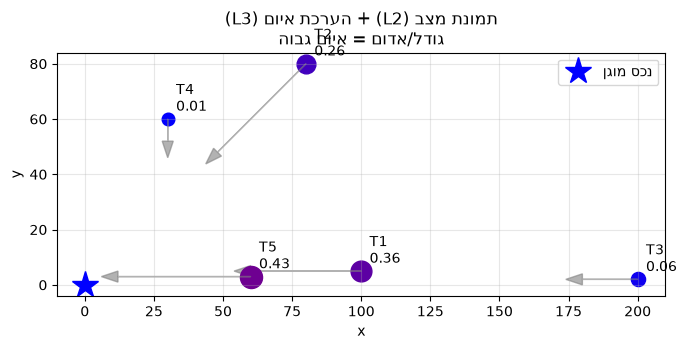

In [2]:
# ויזואליזציה של תמונת המצב (L2) ודירוג האיום (L3)
plt.figure(figsize=(7,6))
plt.plot(*asset,'b*',ms=20,label='נכס מוגן')
for t in tgts:
    p,v=t['pos'],t['vel']
    plt.scatter(*p,s=80+400*t['threat'],c=[[t['threat'],0,1-t['threat']]])
    plt.arrow(p[0],p[1],v[0]*4,v[1]*4,head_width=4,color='gray',alpha=.6)
    plt.annotate(f"{t['name']}\n{t['threat']:.2f}",p,textcoords='offset points',xytext=(6,6))
plt.title('תמונת מצב (L2) + הערכת איום (L3)\nגודל/אדום = איום גבוה'); plt.gca().set_aspect('equal')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## ג. מדדי הערכה (MOP/MOE) — הקושי שהדגיש Blasch
Blasch מדגיש ש**הערכת מערכות fusion קשה** (מורכבות, חסינות, יכולת-פעולה-הדדית). מבחינים בין:
* **MOP (Measures of Performance)** — מדדים טכניים נמוכי-רמה: RMSE, $P_D/P_{FA}$, זמן ריצה.
* **MOE (Measures of Effectiveness)** — האם המשימה הושגה: דיוק דירוג האיום, אזהרה בזמן, עומס על המפעיל.
מדד נפוץ לאיכות החלטה: **שטח מתחת ל-ROC (AUC)**.

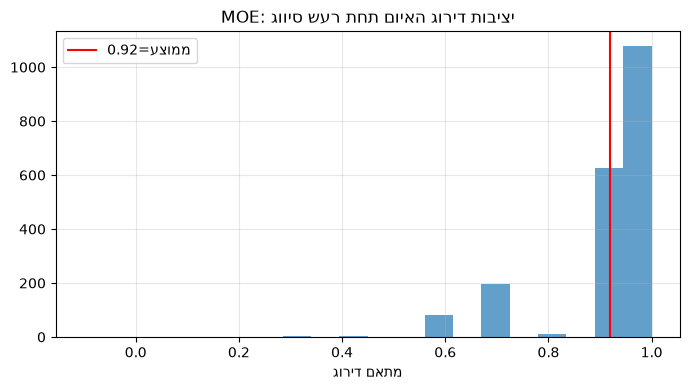

In [3]:
# MOE: האם דירוג האיום שלנו מתאם לאיום ה'אמיתי'? (Monte-Carlo עם רעש סיווג)
def trial():
    order_est=[]; order_true=[]
    for t in tgts:
        p_obs=np.clip(t['p_host']+0.2*rng.standard_normal(),0,1)  # סיווג רועש
        f_cpa=np.exp(-t['cpa']/20); f_tti=np.exp(-t['tti']/15)
        order_est.append(p_obs*f_cpa*f_tti)
        order_true.append(t['threat'])
    # Spearman-like: התאמת סדר העדיפויות
    re=np.argsort(np.argsort(-np.array(order_est)))
    rt=np.argsort(np.argsort(-np.array(order_true)))
    return np.corrcoef(re,rt)[0,1]
corrs=[trial() for _ in range(2000)]
plt.figure(figsize=(7,4)); plt.hist(corrs,bins=20,alpha=.7)
plt.axvline(np.mean(corrs),color='r',label=f'ממוצע={np.mean(corrs):.2f}')
plt.title('MOE: יציבות דירוג האיום תחת רעש סיווג'); plt.xlabel('מתאם דירוג'); plt.legend()
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## ד. Hard + Soft Fusion והאדם בלולאה (L5)
fusion ברמה גבוהה משלב מקורות **hard** (חיישנים פיזיקליים) עם מקורות **soft** (דיווחי אדם, טקסט, מודיעין). 
Blasch מדגיש ש-fusion **אינו** מחליף הסקה אנושית אלא תומך בה (L5): הצגה, הסבר, ואינטראקציה. 
האתגרים הפתוחים שמנה במבוא: מידול **כוונה (intent)**, יריב **תגובתי אינטליגנטי**, וצורך ב**בעיות אתגר משותפות** 
(common challenge problems) ובהערכה סטנדרטית להשוואה ושחזור.

## סיכום
* רמות **L2–L5** עוברות מ'עצמים' ל'משמעות': מצב, איום, ניהול תהליך, ואדם בלולאה.
* הערכת איום משלבת **קינמטיקה (CPA/TTI)** עם **זהות (P(hostile))** — חיבור של מחברות 03–07.
* יש להבחין בין **MOP** (ביצועים טכניים) ל-**MOE** (הצלחת המשימה); הערכת fusion ברמה גבוהה נותרת קשה.
* היעד: **hard+soft fusion** התומך בהסקה אנושית — סגירת המעגל חזרה לעקרונות במחברת 01.